# Notebook 02 — Data Preprocessing

**What this does:**
1. Loads raw GTD data
2. Cleans column names and missing values
3. Adds ideology labels to every group
4. Adds useful columns (era, severity, decade)
5. Saves final file for all other notebooks

**Run after:** 01_data_setup.ipynb

**Output:** data/processed/gtd_processed.csv

In [1]:
# CELL 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported OK')

Libraries imported OK


In [2]:
# CELL 2 - Load data
real_path   = '../data/raw/gtd.csv'
sample_path = '../data/raw/gtd_sample.csv'

if os.path.exists(real_path):
    df = pd.read_csv(real_path, encoding='latin-1', low_memory=False)
    print(f'Real GTD loaded: {len(df):,} rows')
elif os.path.exists(sample_path):
    df = pd.read_csv(sample_path, low_memory=False)
    print(f'Sample data loaded: {len(df):,} rows')
else:
    raise FileNotFoundError('No data found! Run: python ../src/preprocessing/sample_data_generator.py')

df.head(3)

Real GTD loaded: 181,691 rows


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [3]:
# CELL 3 - Keep only columns we need
KEEP = ['iyear','imonth','iday','country_txt','region_txt','city',
        'attacktype1_txt','targtype1_txt','gname','nkill','nwound',
        'weaptype1_txt','success','suicide','latitude','longitude']

available = [c for c in KEEP if c in df.columns]
df = df[available].copy()
print(f'Kept {len(available)} columns')
print(list(df.columns))

Kept 16 columns
['iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'city', 'attacktype1_txt', 'targtype1_txt', 'gname', 'nkill', 'nwound', 'weaptype1_txt', 'success', 'suicide', 'latitude', 'longitude']


In [4]:
# CELL 4 - Rename columns to readable names
RENAME = {
    'iyear':'year','imonth':'month','iday':'day',
    'country_txt':'country','region_txt':'region',
    'attacktype1_txt':'attack_type','targtype1_txt':'target_type',
    'gname':'group_name','nkill':'killed','nwound':'wounded',
    'weaptype1_txt':'weapon_type'
}
df = df.rename(columns={k:v for k,v in RENAME.items() if k in df.columns})
print('Columns after rename:')
print(list(df.columns))

Columns after rename:
['year', 'month', 'day', 'country', 'region', 'city', 'attack_type', 'target_type', 'group_name', 'killed', 'wounded', 'weapon_type', 'success', 'suicide', 'latitude', 'longitude']


In [5]:
# CELL 5 - Fix missing values
for col in ['killed','wounded']:
    if col in df.columns:
        df[col] = df[col].replace([-99,-9], np.nan)
        df[col] = df[col].clip(lower=0)
        df[col] = df[col].fillna(0).astype(int)

for col in ['group_name','country','region','attack_type','target_type','weapon_type','city']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()
        df[col] = df[col].replace({'nan':'Unknown','':'Unknown'})

for col in ['month','day']:
    if col in df.columns:
        df[col] = df[col].replace(0,1).clip(1,28)

for col in ['success','suicide']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('Data cleaned OK')

Missing values remaining: 9113
Data cleaned OK


In [6]:
# CELL 6 - Add ideology labels
IDEOLOGY_MAP = {
    'Taliban':'Religious Extremist',
    'Islamic State of Iraq and the Levant (ISIL)':'Religious Extremist',
    'Al-Qaida':'Religious Extremist',
    'Al-Qaida in the Arabian Peninsula (AQAP)':'Religious Extremist',
    'Al-Qaida in the Islamic Maghreb (AQIM)':'Religious Extremist',
    'Al-Shabaab':'Religious Extremist',
    'Boko Haram':'Religious Extremist',
    'Lashkar-e-Taiba (LeT)':'Religious Extremist',
    'Jaish-e-Mohammed (JeM)':'Religious Extremist',
    'Hamas (Islamic Resistance Movement)':'Religious Extremist',
    'Hezbollah':'Religious Extremist',
    'Palestinian Islamic Jihad (PIJ)':'Religious Extremist',
    'Tehrik-i-Taliban Pakistan (TTP)':'Religious Extremist',
    'Jemaah Islamiyah (JI)':'Religious Extremist',
    'Abu Sayyaf Group (ASG)':'Religious Extremist',
    "Lord's Resistance Army (LRA)":'Religious Extremist',
    'Army of God':'Religious Extremist',
    'Kach':'Religious Extremist',
    'Kahane Chai':'Religious Extremist',
    'Jewish Defense League (JDL)':'Religious Extremist',
    'Babbar Khalsa International (BKI)':'Religious Extremist',
    'Aum Shinrikyo':'Religious Extremist',
    'Liberation Tigers of Tamil Eelam (LTTE)':'Ethno-Nationalist',
    'Irish Republican Army (IRA)':'Ethno-Nationalist',
    'Provisional Irish Republican Army (PIRA)':'Ethno-Nationalist',
    'Euskadi Ta Askatasuna (ETA)':'Ethno-Nationalist',
    'Kurdistan Workers Party (PKK)':'Ethno-Nationalist',
    'Palestine Liberation Organization (PLO)':'Ethno-Nationalist',
    'Kosovo Liberation Army (KLA)':'Ethno-Nationalist',
    'Baloch Liberation Army (BLA)':'Ethno-Nationalist',
    'Revolutionary Armed Forces of Colombia (FARC)':'Left-Wing',
    'Red Army Faction (RAF)':'Left-Wing',
    'Red Brigades':'Left-Wing',
    'Weather Underground':'Left-Wing',
    'Naxalites':'Left-Wing',
    "New People's Army (NPA)":'Left-Wing',
    'Shining Path (SL)':'Left-Wing',
    'Communist Party of India - Maoist (CPI-M)':'Left-Wing',
    'Ku Klux Klan':'Right-Wing',
    'National Alliance':'Right-Wing',
    'Aryan Nations':'Right-Wing',
    'Proud Boys':'Right-Wing',
    'Golden Dawn':'Right-Wing',
    'Unknown':'Unknown',
}

RELIGION_MAP = {
    'Taliban':'Islamic',
    'Islamic State of Iraq and the Levant (ISIL)':'Islamic',
    'Al-Qaida':'Islamic','Al-Shabaab':'Islamic','Boko Haram':'Islamic',
    'Lashkar-e-Taiba (LeT)':'Islamic',
    'Hamas (Islamic Resistance Movement)':'Islamic',
    'Hezbollah':'Islamic','Tehrik-i-Taliban Pakistan (TTP)':'Islamic',
    "Lord's Resistance Army (LRA)":'Christian',
    'Army of God':'Christian',
    'Kach':'Jewish','Kahane Chai':'Jewish',
    'Jewish Defense League (JDL)':'Jewish',
    'Babbar Khalsa International (BKI)':'Sikh',
    'Aum Shinrikyo':'Cult',
}

df['ideology']         = df['group_name'].map(IDEOLOGY_MAP).fillna('Unknown')
df['religion_subtype'] = df['group_name'].map(RELIGION_MAP)

print('Ideology distribution:')
print(df['ideology'].value_counts().to_string())

Ideology distribution:
ideology
Unknown                143132
Religious Extremist     23676
Left-Wing               10165
Ethno-Nationalist        4691
Right-Wing                 27


In [7]:
# CELL 7 - Add extra useful columns
df['total_casualties'] = df['killed'] + df['wounded']
df['severity_score']   = df['killed'] * 2 + df['wounded']
df['is_mass_casualty'] = (df['killed'] >= 10).astype(int)

if 'year' in df.columns:
    df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'

    def get_era(y):
        if   y < 1980: return 'Cold War 1970s'
        elif y < 1990: return 'Cold War 1980s'
        elif y < 2001: return 'Post-Cold War'
        elif y < 2010: return 'Post 9/11'
        elif y < 2015: return 'ISIS Rise'
        else:          return 'Recent 2015+'

    df['era'] = df['year'].apply(get_era)

print('New columns added: total_casualties, severity_score, is_mass_casualty, decade, era')
print(f'Final shape: {df.shape}')

New columns added: total_casualties, severity_score, is_mass_casualty, decade, era
Final shape: (181691, 23)


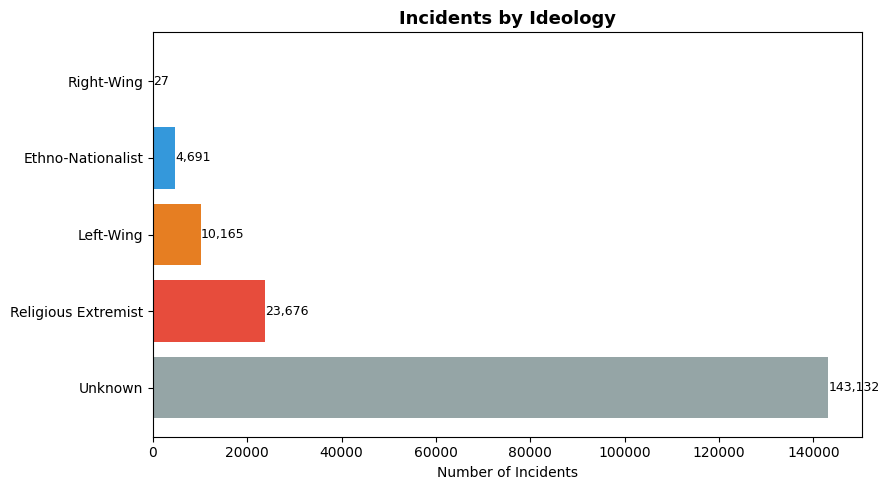

Chart saved to data/processed/ideology_distribution.png


In [8]:
# CELL 8 - Show ideology chart
COLORS = {
    'Religious Extremist':'#e74c3c',
    'Ethno-Nationalist':'#3498db',
    'Left-Wing':'#e67e22',
    'Right-Wing':'#9b59b6',
    'Single Issue':'#2ecc71',
    'Unknown':'#95a5a6'
}

counts = df['ideology'].value_counts()
colors = [COLORS.get(i,'#bdc3c7') for i in counts.index]

fig, ax = plt.subplots(figsize=(9,5))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_title('Incidents by Ideology', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Incidents')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/processed/ideology_distribution.png', dpi=150)
plt.show()
print('Chart saved to data/processed/ideology_distribution.png')

In [9]:
# CELL 9 - Save the final processed file
os.makedirs('../data/processed', exist_ok=True)
out = '../data/processed/gtd_processed.csv'
df.to_csv(out, index=False)

print(f'SAVED: {out}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {df.shape[1]}')
print()
print('DONE! Next step -> Run notebooks/03_eda.ipynb')

SAVED: ../data/processed/gtd_processed.csv
Rows   : 181,691
Columns: 23

DONE! Next step -> Run notebooks/03_eda.ipynb
